In [ ]:
Path(RAW_DIR).mkdir(parents=True, exist_ok=True)

print("Downloading GTSRB training set...")
train_dataset = dsets.GTSRB(root=RAW_DIR, split="train", download=True)

print("Downloading GTSRB test set...")
test_dataset = dsets.GTSRB(root=RAW_DIR, split="test", download=True)

print(f"\nTrain samples : {len(train_dataset):,}")
print(f"Test samples  : {len(test_dataset):,}")


Train samples : 26,640
Test samples  : 12,630


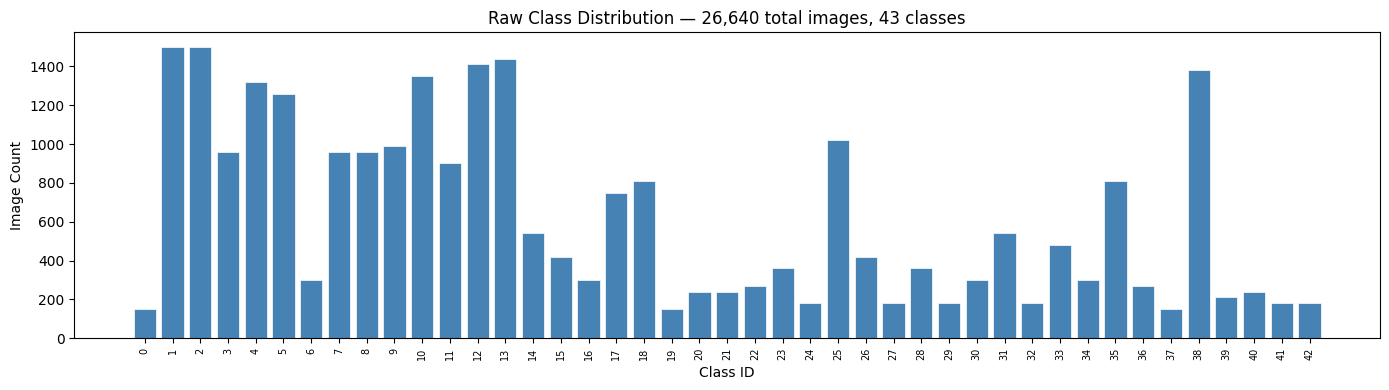

Min images in a class : 150
Max images in a class : 1500
Mean per class        : 620


In [ ]:
raw_counts = {}
for _, label in train_dataset:
    raw_counts[label] = raw_counts.get(label, 0) + 1

classes = sorted(raw_counts.keys())
counts  = [raw_counts[c] for c in classes]

plt.figure(figsize=(14, 4))
plt.bar(classes, counts, color="steelblue", edgecolor="white", linewidth=0.5)
plt.xlabel("Class ID")
plt.ylabel("Image Count")
plt.title(f"Raw Class Distribution — {len(train_dataset):,} total images, {len(classes)} classes")
plt.xticks(classes, rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f"Min images in a class : {min(counts)}")
print(f"Max images in a class : {max(counts)}")
print(f"Mean per class        : {sum(counts)/len(counts):.0f}")


In [ ]:
def sample_per_class(dataset, max_per_class, seed=42):
    random.seed(seed)
    buckets = {}
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        buckets.setdefault(label, []).append(idx)

    sampled = []
    for label, indices in sorted(buckets.items()):
        chosen = random.sample(indices, min(max_per_class, len(indices)))
        sampled.extend(chosen)

    return sampled

print(f"Sampling up to {MAX_PER_CLASS} images per class...")
sampled_indices = sample_per_class(train_dataset, MAX_PER_CLASS, seed=SEED)
print(f"Total sampled: {len(sampled_indices):,} images")

In [ ]:
def preprocess(pil_img, img_size):
    img = pil_img.convert("RGB")
    min_dim = min(img.size)
    if min_dim < 20:
        return None

    img = ImageOps.fit(
        img,
        (img_size, img_size),
        method=Image.Resampling.LANCZOS,
        centering=(0.5, 0.5),
    )
    return img


def build_processed_dataset(dataset, indices, output_dir, img_size):
    img_dir = Path(output_dir) / "images"
    img_dir.mkdir(parents=True, exist_ok=True)
    manifest_path = Path(output_dir) / "manifest.csv"

    rejected = 0
    saved = 0

    with open(manifest_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filename", "class_id"])

        for idx in indices:
            pil_img, label = dataset[idx]
            cleaned = preprocess(pil_img, img_size)
            if cleaned is None:
                rejected += 1
                continue

            filename = f"{saved:06d}_class{label:02d}.png"
            cleaned.save(img_dir / filename)
            writer.writerow([filename, label])
            saved += 1

    print(f"Saved   : {saved:,} images → {img_dir}")
    print(f"Rejected: {rejected} images (too small)")
    print(f"Manifest: {manifest_path}")
    return manifest_path

print("Cleaning and saving images...")
manifest_path = build_processed_dataset(
    train_dataset, sampled_indices, PROCESSED_DIR, IMAGE_SIZE
)


In [ ]:
class RoadSignDataset(Dataset):
    def __init__(self, processed_dir, img_size, use_labels=True):
        self.img_dir = Path(processed_dir) / "images"
        self.manifest = []
        self.use_labels = use_labels

        with open(Path(processed_dir) / "manifest.csv") as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.manifest.append((row["filename"], int(row["class_id"])))

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.5, 0.5, 0.5],
                std=[0.5, 0.5, 0.5],
            ),
        ])

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        filename, class_id = self.manifest[idx]
        img = Image.open(self.img_dir / filename).convert("RGB")
        image = self.transform(img)
        if self.use_labels:
            return image, class_id
        return image


road_sign_dataset = RoadSignDataset(PROCESSED_DIR, IMAGE_SIZE, use_labels=True)
print(f"Dataset size: {len(road_sign_dataset):,} images")


In [ ]:
def plot_sample_grid(dataset, n=64):
    indices = random.sample(range(len(dataset)), min(n, len(dataset)))
    cols = 8
    rows = (len(indices) + cols - 1) // cols

    _, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        tensor, class_id = dataset[idx]
        img_np = (tensor.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1)
        axes[i].imshow(img_np)
        axes[i].set_title(f"C{class_id}", fontsize=6)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("Preprocessed GTSRB Samples (denormalized for display)", fontsize=11)
    plt.tight_layout()
    plt.savefig(Path(PROCESSED_DIR) / "sample_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Sample grid saved.")

plot_sample_grid(road_sign_dataset, n=64)


In [ ]:
manifest_file = Path(PROCESSED_DIR) / "manifest.csv"
img_root = Path(PROCESSED_DIR) / "images"

file_paths = []
labels = []
with open(manifest_file) as f:
    reader = csv.DictReader(f)
    for row in reader:
        file_paths.append(str(img_root / row["filename"]))
        labels.append(int(row["class_id"]))

train = tf.data.Dataset.from_tensor_slices(file_paths)


def preprocess_path(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE), method="bilinear", antialias=True)
    img = tf.cast(img, tf.float32) / 255.0
    return img


train = train.map(preprocess_path, num_parallel_calls=tf.data.AUTOTUNE)
train = train.shuffle(min(len(file_paths), 1000), seed=SEED)
train = train.batch(BATCH_SIZE, drop_remainder=True)
train = train.prefetch(tf.data.AUTOTUNE)
train = train.repeat(DATASET_REPETITIONS)

print(f"Prepared tf.data train pipeline with {len(file_paths):,} images")

2026-05-02 17:02:35.191116: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-02 17:02:35.191321: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-02 17:02:35.191337: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-02 17:02:35.191575: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-02 17:02:35.191792: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Prepared tf.data train pipeline with 430 images
